In [1]:
import numpy as np
import pandas as pd
import patato as pat

from pathlib import Path

from mpl_toolkits.axes_grid1 import ImageGrid
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

import matplotlib.pyplot as plt
from paiskintonetools import setup_matplotlib  #  type:ignore

setup_matplotlib(dpi=300)

%config InlineBackend.print_figure_kwargs = {'bbox_inches':None}

In [2]:
import json

settings = json.load(open("../data_paths.json", "r"))
root_data_path = (Path.cwd() / "../" / settings["main_data_path"]).resolve()

In [3]:
root = root_data_path
roi_source = root / "SKIN01/Scan_1.hdf5"
roi_source = pat.PAData.from_hdf5(roi_source)
roi_source.set_default_recon(["Model Based", "0"])  #  type:ignore

example_image = root / "SKIN43/Scan_1.hdf5"
example_image = pat.PAData.from_hdf5(example_image)
example_image.set_default_recon(["Model Based", "0"])  #  type:ignore

scans = []
ids = []
for p in root.glob("**/*.hdf5"):
    pa = pat.PAData.from_hdf5(p)
    if pa.get_scan_name() == "phantom":
        # print(p.parent.stem)
        pa.set_default_recon(["Model Based", "0"])  #  type:ignore
        scans.append(pa)
        ids.append(p.parent.stem)

In [4]:
masks = {}

for i in "0123":
    roi = roi_source.get_rois()["phantom_", i]
    roi_mask, _ = roi.to_mask_slice(roi_source.get_scan_reconstructions())  #  type:ignore
    masks[i] = roi_mask

In [5]:
scans[0].get_scan_datetime()

datetime.datetime(2023, 6, 22, 14, 3, 6, 104702)

In [6]:
all_wavelengths = list(range(680, 1110, 10))

In [7]:
results = []

for s, n in zip(scans, ids):
    for i in "0123":
        r = {}
        r["Time"] = s.get_scan_datetime()
        r["SkinID"] = n
        r["ROI ID"] = i

        mask = masks[i]
        rec = s.get_scan_reconstructions().raw_data.T[mask.T].T
        rec[rec < 0] = np.nan
        spec = np.nanmean(rec, axis=(0, -1))
        spec_full = np.full(len(all_wavelengths), np.nan)

        wls = s.get_wavelengths()
        spec_full[
            all_wavelengths.index(wls[0]) : all_wavelengths.index(wls[-1]) + 1
        ] = spec
        r["Spec"] = spec_full
        results.append(r)

/var/folders/j_/tr170khd4szcb58bp9qlz61r0000gp/T/ipykernel_74236/122859484.py:13: RuntimeWarning: Mean of empty slice
  spec = np.nanmean(rec, axis=(0, -1))
/var/folders/j_/tr170khd4szcb58bp9qlz61r0000gp/T/ipykernel_74236/122859484.py:13: RuntimeWarning: Mean of empty slice
  spec = np.nanmean(rec, axis=(0, -1))


In [8]:
df = pd.DataFrame(results)

columns = ["SkinID", "ROI ID"]
for i, w in enumerate(all_wavelengths):
    columns.append(f"{w:.0f} nm")
    df[f"{w:.0f} nm"] = df["Spec"].apply(lambda x: x[i])
df[columns].to_csv("../Analysis/plotted_data/figureS8.csv")

[ 4.66403065  7.43843767  5.41208263  3.69394546  3.30062578  2.93383806
  3.50191063  2.87063101  3.15267984  3.69578342  3.38454225  3.3981418
  3.27364539  3.75247754  4.22901851  4.20998493  4.94007097  5.06938693
  6.10349542  7.05565585  8.38264735 12.58663611 15.18961036 17.58520717
 16.87002308 18.59929993 20.7491689   9.69921053  9.76494926 10.05808152
  8.6592686   9.33175494  6.85640872  5.84688814  9.80390468  9.24519833
 12.75498422 15.60303641  7.90565871  6.03858128  7.58195377  6.6973026
  8.52424044]
[ 6.44427549  9.60459917  7.94016413  7.63182953  6.81319635  6.83146884
  7.38787026  7.36538233  7.69535953  8.68564368  7.91235237  7.71096955
  7.67401984  8.68878534  9.46015817 10.07818971  9.17119542  6.74070287
  6.81953201  8.82264888  8.83914177  8.79290977  8.8661068  13.15860688
 11.3869939  24.06861211  8.92012487 10.72389543 11.37100338  8.00475346
  9.57957364 11.60641352 14.02118031 13.2360848  12.6919781  14.63712822
 13.79337672 14.49963241 12.98815762 10

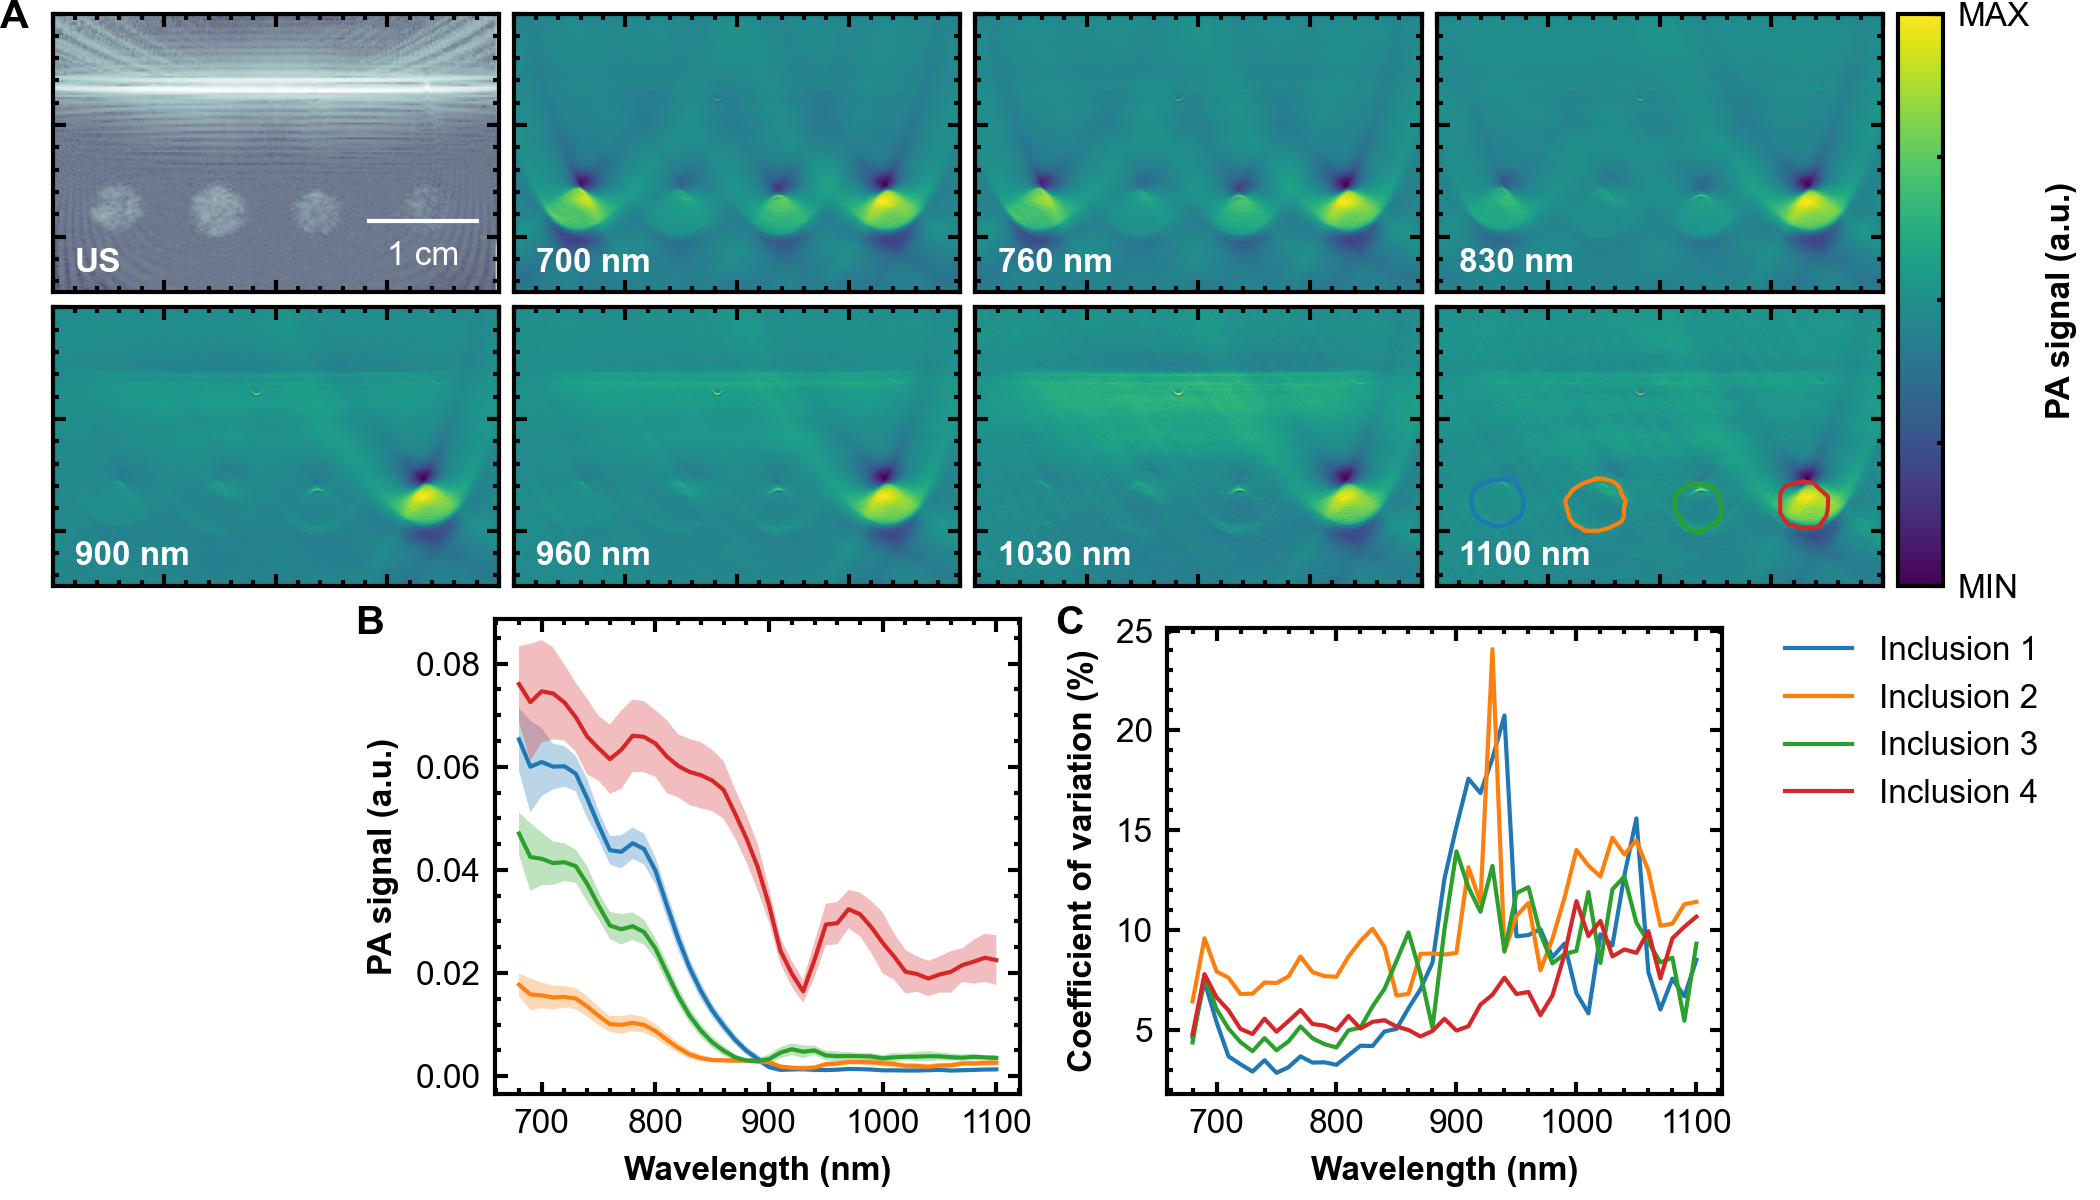

In [ ]:
fig = plt.figure(figsize=(7, 4))

subfiga, subfigb = fig.subfigures(2)

subfigbs = subfigb.subfigures(1, 4, width_ratios=[0.5, 1, 1, 0.5])

subfiga.text(0, 1, "A", va="top", ha="left", fontsize="large", fontweight="bold")

ax = subfigbs[1].subplots()
subfigbs[1].text(0, 1, "B", va="top", ha="left", fontsize="large", fontweight="bold")
for n, g in df.groupby("ROI ID"):
    m = np.nanmean(np.vstack(g["Spec"]), axis=0)  #  type:ignore
    N = np.sum(~np.isnan(np.vstack(g["Spec"])), axis=0)  #  type:ignore
    s = np.nanstd(np.vstack(g["Spec"]), axis=0)  # / np.sqrt(N) #  type:ignore
    ax.plot(all_wavelengths, m, label=f"Inc. {int(n) + 1}")  #  type:ignore
    ax.fill_between(all_wavelengths, m - s * 2, m + s * 2, alpha=0.3)
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("PA signal (arb. units)")
# ax.legend()

ax = subfigbs[2].subplots()
subfigbs[2].text(0, 1, "C", va="top", ha="left", fontsize="large", fontweight="bold")
for n, g in df.groupby("ROI ID"):
    m = np.nanmean(np.vstack(g["Spec"]), axis=0)  #  type:ignore

    N = np.sum(~np.isnan(np.vstack(g["Spec"])), axis=0)  #  type:ignore
    s = np.nanstd(np.vstack(g["Spec"]), axis=0)  # / np.sqrt(N)  #  type:ignore
    cov = 100 * s / m
    print(cov)

    ax.plot(all_wavelengths, cov, label=f"Inclusion {int(n) + 1}")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Coefficient of variation (%)")
subfigbs[3].legend(*ax.get_legend_handles_labels(), loc="upper left")

axes_images = ImageGrid(
    subfiga,
    (0.025, 0.005, 0.9, 0.98),  # similar to subplot(111)
    nrows_ncols=(2, 4),
    axes_pad=0.05,  # pad between Axes in inch.
    share_all=True,
    label_mode="all",
    cbar_mode="single",
)
axes_images[0].set_ylim([-0.015, 0.01])
axes_images[0].set_xlim([-0.02, 0.02])
for ax in axes_images:
    ax.yaxis.set_tick_params(labelleft=False)
    ax.xaxis.set_tick_params(labelbottom=False)

recs = example_image.get_scan_reconstructions()

us = example_image.get_ultrasound()
axes_images[0].imshow(
    us.raw_data[0, 0, :, 0],  #  type:ignore
    cmap="bone",
    extent=us.extent,  #  type:ignore
    origin="lower",
)
axes_images[0].text(
    0.05,
    0.05,
    "US",
    va="bottom",
    ha="left",
    transform=axes_images[0].transAxes,
    fontweight="bold",
    color="white",
)

for ax, n in zip(
    axes_images[1:],
    np.linspace(0, recs.shape[1] - 1, len(axes_images) - 1).astype(int),  #  type:ignore
):
    im = ax.imshow(recs.raw_data[0, n, :, 0], extent=recs.extent, origin="lower")  #  type:ignore
    wl = example_image.get_wavelengths()[n]
    ax.text(
        0.05,
        0.05,
        f"{wl:.0f} nm",
        va="bottom",
        ha="left",
        transform=ax.transAxes,
        fontweight="bold",
        color="white",
    )

for i in "0123":
    roi = roi_source.get_rois()["phantom_", i]
    lines = roi.plot(ax=axes_images[-1])
    lines[0].set_color("C" + i)

asb = AnchoredSizeBar(
    axes_images[0].transData,
    0.01,
    "1 cm",
    loc="lower right",
    pad=0.1,
    borderpad=0.5,
    sep=5,
    frameon=False,
    color="white",
)
axes_images[0].add_artist(asb)

cbar = axes_images.cbar_axes[0].colorbar(im)  #  type:ignore
cbar.set_label("PA signal (arb. units)")

cbar.ax.set_yticks([im.get_clim()[0], im.get_clim()[1]], ["MIN", "MAX"])  #  type:ignore

fig.savefig("phantom_characterisation.pdf", dpi=300)
plt.show()